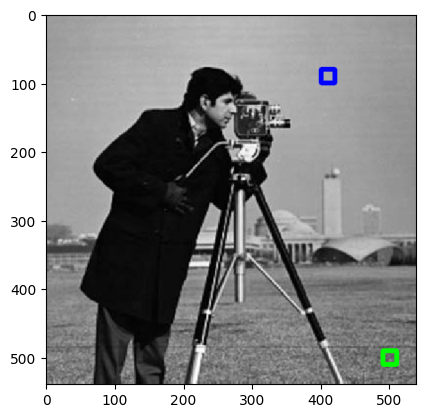

In [2]:
# SELECCIÓN DE PUNTOS DE REFERENCIA PARA SEGMENTACIÓN POR COLOR

import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/photographer.png')

# Dibujar dos pequeños rectángulos para marcar zonas de muestreo de color:
# Rectángulo rojo  (0,0,255) → muestra el color del OBJETO de interés (fotógrafo)
#   en la posición (400,80)-(420,100)
window = cv2.rectangle(img.copy(), (400, 80), (420, 100), (0, 0, 255), 5)

# Rectángulo verde (0,255,0) → muestra el color del FONDO
#   en la posición (490,490)-(510,510)
window = cv2.rectangle(window, (490, 490), (510, 510), (0, 255, 0), 5)

plt.imshow(window, cmap='gray')
plt.show()

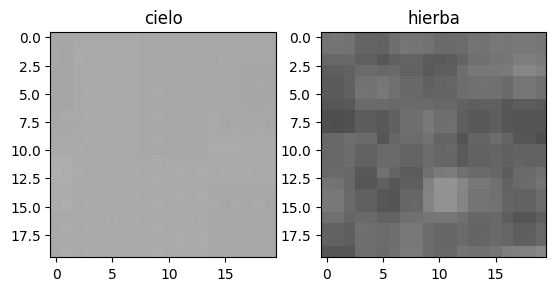

In [3]:
# Seleccionamos una región del cielo y una de la hierba

# Extraer las mismas zonas marcadas por los rectángulos anteriores
# img[filas, columnas] → mismas coordenadas que los rectángulos del paso anterior
cielo  = img[80:100, 400:420]   # región del cielo  (rectángulo rojo)
hierba = img[490:510, 490:510]  # región de la hierba (rectángulo verde)

# Visualizar las dos muestras de color
fig, ax = plt.subplots(1, 2)
ax[0].imshow(cielo,  cmap='gray'), ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray'), ax[1].set_title('hierba')
plt.show()

### MATRIZ DE COOCURRENCIA

In [14]:
# MATRIZ DE COOCURRENCIA (GLCM) PARA DESCRIBIR TEXTURA

from tabulate import tabulate
from skimage.feature import graycomatrix, graycoprops

headers = ['', 'cielo', 'hierba']

# Inicializar listas con el nombre del descriptor como primer elemento
CN, DIS, H, ASM, E, COR = ['contraste'], ['disimilitud'], ['homogeneidad'], ['ASM'], ['Energía'], ['Correlación']

# Lista con las dos regiones muestreadas en el paso anterior
patches = []
patches.append(cielo)
patches.append(hierba)

for i in range(len(patches)):
    # Convertir cada región a grises (GLCM trabaja con un solo canal)
    image = cv2.cvtColor(patches[i], cv2.COLOR_BGR2GRAY)

    # Calcular la GLCM:
    # distances=[5]  → analiza pares de píxeles separados 5 posiciones
    # angles=[0]     → solo en dirección horizontal (0 radianes)
    # levels=256     → niveles de gris posibles
    # symmetric=True → la matriz es simétrica (cuenta ambas direcciones)
    # normed=True    → normalizada (valores entre 0 y 1)
    GLCM = graycomatrix(image, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

    # Extraer propiedades de la GLCM (el [0,0] accede al valor para distance=5, angle=0)
    CN.append(graycoprops(GLCM, 'contrast')[0,0])      # variación de intensidad entre vecinos
    DIS.append(graycoprops(GLCM, 'dissimilarity')[0,0]) # similar al contraste pero lineal
    H.append(graycoprops(GLCM, 'homogeneity')[0,0])    # uniformidad (1=muy homogéneo)
    ASM.append(graycoprops(GLCM, 'ASM')[0,0])          # Angular Second Moment: uniformidad al cuadrado
    E.append(graycoprops(GLCM, 'energy')[0,0])         # raíz del ASM
    COR.append(graycoprops(GLCM, 'correlation')[0,0])  # dependencia lineal entre píxeles vecinos

my_data = [tuple(CN), tuple(DIS), tuple(H), tuple(ASM), tuple(E), tuple(COR)]

print(tabulate(my_data, headers=headers))

                 cielo        hierba
------------  --------  ------------
contraste     3.68      333.393
disimilitud   1.4        13.8533
homogeneidad  0.512471    0.0921279
ASM           0.142717    0.00510556
Energía       0.377779    0.0714532
Correlación   0.190521   -0.0705127


### Scale-Invariant Feature Transform

(1672, 128)


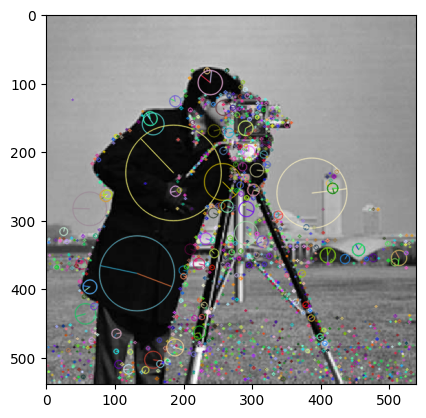

In [17]:
# SIFT algorithm
img = cv2.imread('images/photographer.png')

# Definición del algoritmo
sift = cv2.SIFT_create()

# Identificamos los puntos de interés (key points)
kp = sift.detect(img, None)

# Extraemos el descriptor para obtener el fingreprint
kp, des = sift.compute(img, kp)
print(np.shape(des))
# print(des) # Matriz donde las filas son los keypoints y las columnas las características de dichos puntos clave

# Visualizamos los puntos de interés
img=cv2.drawKeypoints(img, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()

# 1672 key points
# una firma de 128 valores

Circulo: direccion y longitud del gradiente

### Histogram of Oriented Gradients

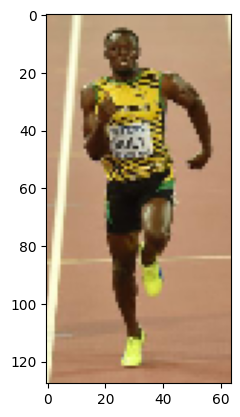

In [19]:
# HISTOGRAM OF ORIENTED GRADIENTS (HOG)

# Cargar imagen y normalizar a rango [0, 1]
from skimage import io
img = io.imread('images/pedestrian.jpg')
img = np.float32(img / 255)  # normalizar: uint8 [0,255] → float32 [0,1]

# Recortar la región de interés (ROI) donde está el peatón
crop = img[75:550, 475:700]

# Redimensionar al tamaño estándar de HOG para detección de personas: 64x128
# Este tamaño es el estándar del paper original de Dalal & Triggs (2005)
crop = cv2.resize(crop, (64, 128))

plt.imshow(crop, cmap='gray')
plt.show()

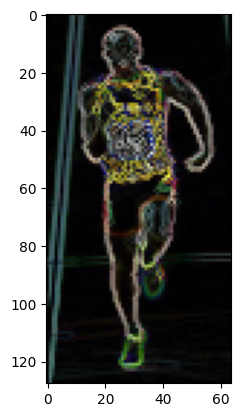

In [21]:
# CÁLCULO DEL GRADIENTE CON SOBEL

crop = np.float32(crop)

# Sobel calcula la derivada parcial en cada dirección:
# gx → gradiente horizontal (detecta bordes verticales)  dx=1, dy=0
# gy → gradiente vertical   (detecta bordes horizontales) dx=0, dy=1
# ksize=1 → kernel 1x3 o 3x1 (el más pequeño posible)
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)

# Combinar gx y gy en magnitud y ángulo (coordenadas polares)
# mag   → intensidad del gradiente (qué tan fuerte es el borde)
# angle → dirección del gradiente en grados [0, 360]
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Normalizar la magnitud a [0,1] para visualizar correctamente
mag = mag / np.max(mag)
plt.imshow(mag, cmap='gray')
plt.show()

In [28]:
# CÁLCULO DEL DESCRIPTOR HOG

from skimage.feature import hog

# Convertir a grises (aunque luego se usa crop en color en hog())
crop_gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

# Calcular el descriptor HOG sobre la imagen en color (crop)
# Parámetros:
#   orientations=9       → 9 direcciones de gradiente (0°-180° dividido en 9 bins)
#   pixels_per_cell=(8,8)→ cada celda es de 8x8 píxeles
#   cells_per_block=(2,2)→ cada bloque agrupa 2x2 celdas (normalización local)
#   transform_sqrt=True  → normalización gamma antes de calcular (reduce el efecto de la iluminación)
#   block_norm="L1"      → método de normalización dentro de cada bloque
H = hog(crop_gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L1")
# Tamaño del descriptor resultante:
# imagen 64x128 → 8x16 celdas → 7x15 bloques → 7*15*2*2*9 = 3780 valores
np.shape(H)

# 3780 características

(3780,)

### Local Binary Patterns

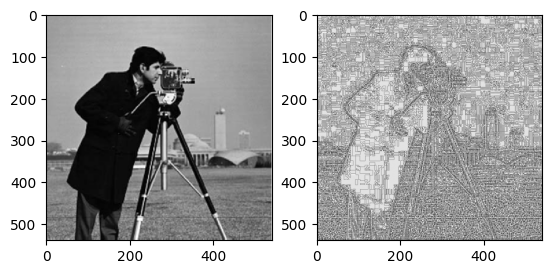

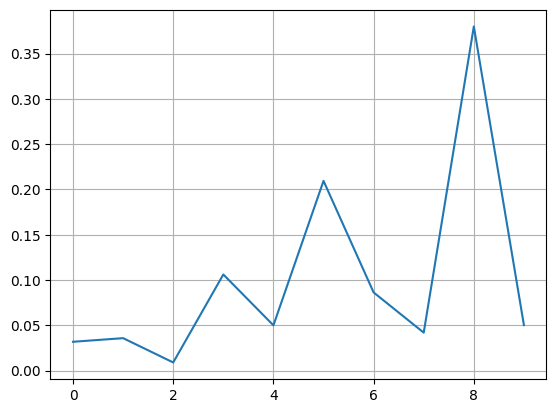

In [29]:
# LOCAL BINARY PATTERNS (LBP)
from skimage.feature import local_binary_pattern
img = cv2.imread('images/photographer.png')

# Definimos los parámetros iniciales
R = 1 # Radio
P = 8*R # Número de píxeles vecinos
epsilon = 1e-7 # Para normalizar el histograma

# Extraemos la imagen LBP
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
lbp_image = local_binary_pattern(img_gray, P, R, method='uniform')
a,b = np.unique(lbp_image, return_counts=True)

# Calculamos el histograma
lbp_image = np.uint8(lbp_image)
hist = cv2.calcHist([lbp_image.ravel()], [0], None, [P+2], [0, P+2])

# Normalizamos el histograma
hist = hist.astype("float")
hist /= (hist.sum() + epsilon)

# Los P+2=10 bins del histograma serán los 10 atributos que nos permitirán caracterizar una imagen

# Visualizamos la imagen LBP
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(lbp_image, cmap='gray')
plt.show()

# Visualizamos el histograma
plt.plot(hist)
plt.grid(True)
plt.show()

# aqui hay solo 9 características